<a href="https://colab.research.google.com/github/Arjx01/ML2_LAB/blob/main/ML2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [74]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [25]:
df = pd.read_csv("student_data_ml.csv")

In [26]:
print("Dataset:")
print(df)

Dataset:
   Student_ID  Age  Gender  StudyHours  Attendance  Marks Result
0        S001   18    Male         6.2          70     63   Pass
1        S002   19    Male         5.7          89     46   Fail
2        S003   22  Female         1.2          60     62   Fail
3        S004   19    Male         4.9         100     88   Pass
4        S005   19  Female         5.1          55     55   Fail
..        ...  ...     ...         ...         ...    ...    ...
95       S096   18    Male         7.4          62     93   Pass
96       S097   19  Female         5.7          90     75   Pass
97       S098   21  Female         6.8          90     92   Pass
98       S099   19  Female         4.2          70     70   Pass
99       S100   22  Female         5.4          72     91   Pass

[100 rows x 7 columns]


In [27]:
gender_encoder = LabelEncoder()
df["Gender"] = gender_encoder.fit_transform(df["Gender"])

In [28]:
result_encoder = LabelEncoder()
df["Result"] = result_encoder.fit_transform(df["Result"])

In [29]:
X = df[["Age", "Gender", "StudyHours", "Attendance", "Marks"]]
y = df["Result"]

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [70]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 80
Testing samples: 20


In [75]:
model = DecisionTreeClassifier(random_state=42)

In [76]:
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [77]:
y_pred = model.predict(X_test)

In [86]:
print("Actual:", y_test.values)
print("Predicted:", y_pred)

Actual: [1 1 1 1 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 1]
Predicted: [0 1 1 1 1 0 0 1 1 0 0 1 0 1 0 1 1 1 1 1]


In [91]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

In [92]:
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8
Precision: 0.7692307692307693
Recall   : 0.9090909090909091
F1 Score : 0.8333333333333334


In [80]:
cm = confusion_matrix(y_test, y_pred)

In [81]:
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[ 6  3]
 [ 1 10]]


In [82]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

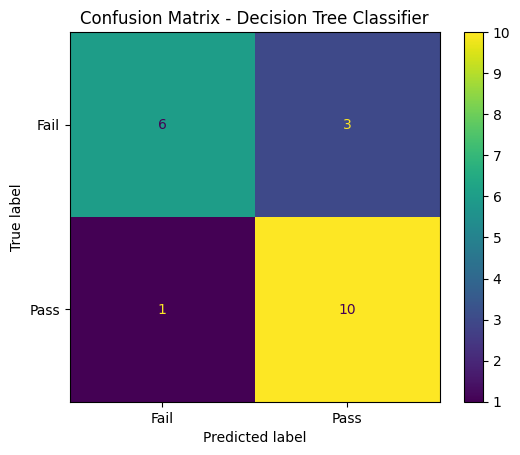

In [84]:
disp.plot()
plt.title("Confusion Matrix - Decision Tree Classifier")
plt.show()